# Poisson and Schrödinger simulation of a single quantum dot in FD-SOI

## Introduction

In this tutorial, we will simulate the Poisson and Schrödinger equations for a single quantum dot in previously defined FD-SOI device. The tutorial will specifically cover:

- Solving the non-linear Poisson equation;
- Implementing adaptive meshing and exploring techniques to ensure convergence of the Poisson equation at cryogenic temperatures;
- Solving the Schrödinger equation by using the solution to the Poisson equaiton;
- Visualizing the results of both the Poisson and Schrödinger solutions.

This tutorial uses the mesh generated in the previous tutorial, “Creating a 3D model of an FD-SOI quantum dot with QTCAD® Builder”, importing it directly for the simulations.

## Simulation

We begin by importing the necessary libraries for this workflow.

In [1]:
# General Python libraries.
from pathlib import Path
import numpy as np
from matplotlib import pyplot as plt

# QTCAD® imports.
from qtcad.device import constants as ct
from qtcad.device import materials as mt
from qtcad.device import analysis as an
from qtcad.device import io
from qtcad.device.mesh3d import Mesh, SubMesh
from qtcad.device import Device, SubDevice
from qtcad.device.poisson import Solver as PoissonSolver
from qtcad.device.poisson import SolverParams as PoissonSolverParams
from qtcad.device.schrodinger import Solver as SchrodingerSolver
from qtcad.device.schrodinger import SolverParams as SchrodingerSolverParams


|  ||  |||                                                                 \\  
|  ||  |||         @@@@     @@@@@@@@      @@@@@        @       @@@@@@@      \\ 
|  ||  |||      @@@   @@@      @@      @@@    @       @@       @@    @@@     \\
|  ||  |||     @@       @@     @@     @@             @ @@      @@     @@@     \\
|  ||  |||     @@       @@     @@     @@            @    @     @@      @@     //
|  ||  |||      @@     @@      @@      @@@    @    @@@@@@@@    @@    @@@     //
|  ||  |||        @@@@@@       @@        @@@@@@   @@      @@   @@@@@@       // 
|  ||  |||             @@                                                  //   

                                 Version 2.1.3                                  
  Copyright (c) 2022-2026 Nanoacademic Technologies Inc. All rights reserved.   

      Welcome to QTCAD, the Quantum-Technology Computer-Aided Design tool.      

                        For documentation, please visit:                        
                      https:/

Next, we define the paths to the mesh (`.msh`) and geometry (`.xao`) files, as well as the destination paths where the simulation outputs will be saved.

In [2]:
# Paths to mesh, geometry and output files.
script_dir = Path("__file__").parent.resolve()
path_mesh_dir = script_dir / "meshes"
path_out = script_dir / "output"
path_mesh = path_mesh_dir / "sqdfdsoi.msh"
path_geo = path_mesh_dir / "sqdfdsoi.xao"

### Defining the gate bias values

Next, we define the parameters for the boundary conditions, which simulate the effect of biases applied to metallic contacts (gates) on the device layout.

The values include the two barrier gates, the plunger gate, and the back gate. The plunger gate is set higher than the barrier gates to attract electrons beneath it.

These parameter values were determined through a trial-and-error optimization process, resulting in the confinement of electron(s) beneath the plunger gate within the silicon channel.

In [3]:
# Gate biases.
barrier_gate_1_bias = 0.55
barrier_gate_2_bias = 0.55
plunger_gate_bias = 0.65
back_gate_bias = -0.47

### 1. Importing and visualizing the mesh

In this step, we import and show the mesh previously generated in the “Creating a 3D model of an FD-SOI quantum dot with QTCAD® Builder” tutorial.

Loading mesh from file:
 C:\Proyecto_QTCAD\meshes\sqdfdsoi.msh
Done.
3D MESH STATISTICS
--------------------------------------------------------------------------------
Total number of elements      6802                
Triangular elements           2324                
Tetrahedral elements          4478                
Total number of nodes         1072                
Boundary physical names       box_side, spacer_1_bottom, spacer_1_side, source_bottom, source_side, spacer_2_bottom, spacer_2_side, drain_bottom, drain_side, channel_bottom, channel_side, gate_oxide_bottom, gate_oxide_side, gate_oxide_top, barrier_gate_2, plunger_gate, barrier_gate_1, back_gate, 
Region physical names         box, spacer_1, source, spacer_2, drain, channel, gate_oxide, 


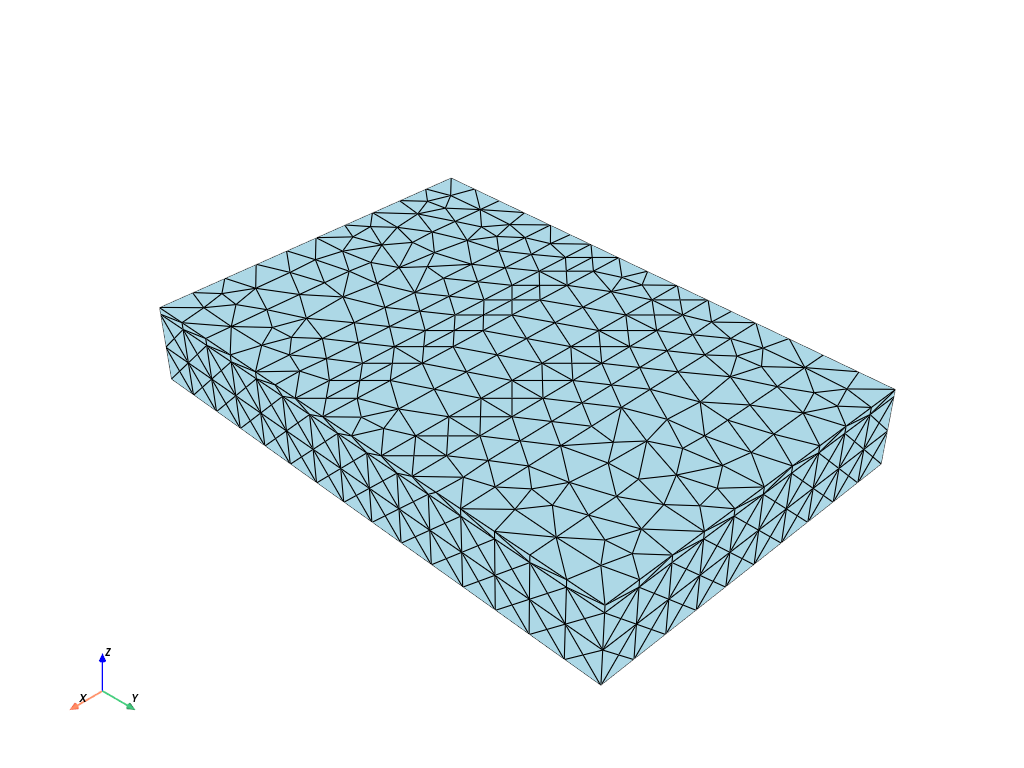

In [4]:
# Load and show the mesh.
mesh = Mesh(1e-9, path_mesh)
mesh.show()

### 2. Creating the `Device` object

We now instantiate the `Device` object required for the QTCAD® simulation.

First, we create the device using the imported mesh, specifying electrons as the charge carriers with `conf_carriers="e"`.

In [5]:
# Instantiate the device.
dvc = Device(mesh, conf_carriers="e")

Next, we set the device temperature to $T = 0.1~\text{K}$.

In [6]:
dvc.set_temperature(0.1)

#### Materials

We then define the 3D regions and assign their material properties with the [`new_region` method 🔗](https://docs.nanoacademic.com/qtcad/API_reference/qtcad.device.device/#qtcad.device.device.Device.new_region).

In this case:

1. The channel is made of silicon.

In [7]:
dvc.new_region("channel", mt.Si)

2. The surrounding oxide is defined as silicon oxide, SiO₂ (`mt.SiO2`).

In [8]:
dvc.new_region("box", mt.SiO2)
dvc.new_region("spacer_1", mt.SiO2)
dvc.new_region("spacer_2", mt.SiO2)

3. The gate dielectric layer (the top $2$ nm) is made of hafnium oxide, HfO₂ (`mt.HfO2`).

In [9]:
dvc.new_region("gate_oxide", mt.HfO2)

4. The source and drain regions are also silicon, but heavily doped at a concentration of $10^{26}~\mathrm{m}^{-3}$(SI units): `ndoping=1e20 * 1e6`.

In [10]:
dvc.new_region("source", mt.Si, ndoping=1e20 * 1e6)
dvc.new_region("drain", mt.Si, ndoping=1e20 * 1e6)

This configuration captures the correct material stack and doping profile required to accurately model the electrostatics and quantum confinement in the device.

#### Boundary conditions

Next, we define the boundary conditions.

In the present case, we use the gate boundary condition. This boundary condition imposes the following potential over the specified boundary:

$\displaystyle
\varphi = \varphi_\mathrm{bias} - E_F/e + \varphi_F-E_w/e,
$

where:

- $\varphi$ is the resulting electrostatic potential at the boundary,
- $\varphi_\mathrm{bias}$ is the user-defined applied bias,
- $E_F$ is the Fermi energy,
- $\varphi_F$ is the reference potential,
- $E_w$ is the work function of the gate material (i.e., the energy required to remove an electron from the metal), and
- $e$ is the elementary charge.

By default, the Fermi energy $E_F$ is set to zero. In addition, a constant reference potential $\varphi_F$ is introduced to define the potential gauge. This reference potential does not affect the device physics, since adding a constant shift to the electric potential corresponds to a gauge transformation and therefore does not modify the electric field.

By default, $\varphi_F$ is chosen to be equal to the work function of intrinsic silicon at the device temperature.

The gate boundary condition is a specialized form of the [Dirichlet boundary condition 🔗](https://docs.nanoacademic.com/qtcad/theory_spin_fem/poisson/#dirichlet-boundaries-api-reference) discussed previously. However, instead of directly prescribing a fixed electrostatic potential, it incorporates additional terms to account for the physical effects of a metallic gate, including its work function.

For more details, see the [`new_gate_bnd` method 🔗](https://docs.nanoacademic.com/qtcad/theory_spin_fem/poisson/#gate-boundaries-api-reference).

This formulation implies that the gate regions are treated as metallic contacts in the simulation.

Here, we define the work function of the metallic gates to correspond to the mid-gap energy of silicon, which represents the energy level located halfway between the conduction band minimum and the valence band maximum of silicon.

In [11]:
# Mid-gap work function
Ew = mt.Si.Eg / 2 + mt.Si.chi

# Define boundary conditions
dvc.new_gate_bnd("barrier_gate_1", barrier_gate_1_bias, Ew)
dvc.new_gate_bnd("barrier_gate_2", barrier_gate_2_bias, Ew)
dvc.new_gate_bnd("plunger_gate", plunger_gate_bias, Ew)
dvc.new_gate_bnd("back_gate", back_gate_bias, Ew)

After instantiating the device and defining its regions and boundary conditions, we can visualize the 3D geometry to verify the setup.

<div class="alert alert-block alert-info">

**Note**

When you run the next cell, a Jupyter widget will appear below it showing the device.
You can freely pan, rotate and zoom, as well as selectively show the different surfaces that make up the device.

</div>

In [28]:
dvc.show()

#### Dot region

As described in the previous tutorial, “Creating a 3D model of an FD-SOI quantum dot with QTCAD® Builder”, the dot region is the part of the device where the quantum dot is expected to form. Within this region, the system is treated quantum mechanically: the carrier states are computed using the Schrödinger solver.

There are two primary ways to define the dot region:

- **Using geometric tags from the mesh**

  In this approach, we pass a string (or a list of strings) corresponding to the tagged regions in the mesh that should be treated as the dot region.

- **Using the corner method**

  In this method, we provide two coordinates defining opposite corners of a 3D box. The dot region is then defined as the box defined by these points.

In this tutorial, we use the corner method. We take the corners corresponding to the edges of the channel region and add a small buffer to define the dot region. As a result, the dot region is slightly larger than the channel itself, allowing it to include the confinement effects arising from interaction with the surrounding oxide in the direction perpendicular to the channel.

---

First we define the buffer parameters:

In [13]:
# Dot region parameters.
buffer_bottom = 10e-9
buffer_top = 2e-9
buffer_leads = 15e-9
buffer_spacers = 5e-9

Next, we create a `SubMesh` corresponding to the channel and use the [mesh attribute `glob_nodes` 🔗](https://docs.nanoacademic.com/qtcad/API_reference/qtcad.device.mesh3d/#qtcad.device.mesh3d.Mesh) to obtain the coordinates of all mesh nodes within this region. By finding the minimum and maximum values of these coordinates, we effectively determine the corners of the channel, since the channel is a rectangular box. (We encourage you to isolate the channel in the visualizer GUI to verify this yourself.)

By adding a small buffer to these coordinates, we define a slightly larger volume for the dot region. The two farthest edges of this buffered box are then passed to the `Device` [method `set_dot_region` 🔗](https://docs.nanoacademic.com/qtcad/API_reference/qtcad.device.device/#qtcad.device.device.Device.set_dot_region).

In [14]:
# Create the dot region:
# · Channel region.
channel = SubMesh(mesh, "channel")
# · Coordinates of channel corners
x0, y0, z0 = channel.glob_nodes.min(axis=0)
x1, y1, z1 = channel.glob_nodes.max(axis=0)
# · Expand by buffers.
z0 -= buffer_bottom
z1 += buffer_top
y0 += buffer_leads
y1 -= buffer_leads
x0 -= buffer_spacers
x1 += buffer_spacers
dot_region_box = [(x0, y0, z0), (x1, y1, z1)]
dvc.set_dot_region(dot_region_box)

3D SUBMESH STATISTICS
--------------------------------------------------------------------------------
Total number of elements      1020                
Triangular elements           434                 
Tetrahedral elements          586                 
Total number of nodes         219                 
Boundary physical names       channel_bottom, channel_side, gate_oxide_bottom, 
Region physical names         channel,                      


### 3. Non-linear Poisson electrostatics

Consider the Poisson equation:

$$
\displaystyle
-\nabla \cdot (\varepsilon \nabla \varphi) = \rho,
$$

where $ \varphi $ is the electrostatic potential and $ \rho $ is the charge density and $\epsilon$ is the permitivity of the material. In the non-linear case, $ \rho $ depends on $ \varphi $, meaning that charges rearrange themselves in response to the potential. This is essential for modeling source and drain regions, where doping induces large charge densities that must be resolved self-consistently.

The total charge density can be written as:

$$
\displaystyle
\rho = \rho_\mathrm{semi} + \rho_0,
$$

where:  

- $ \rho_0 $ is a fixed background charge that can be set with the [method `set_vol_charge_density` 🔗](https://docs.nanoacademic.com/qtcad/API_reference/qtcad.device.device/#qtcad.device.device.Device.set_vol_charge_density) to model additional charges independent of $ \varphi $, e.g., charged defects.

The semiconductor charge density is given by

$$
\rho_\mathrm{semi} = e\left(p - n + N_+ - N_-\right),
$$

where:

- $e$ is the elementary charge,
- $n$ is the electron density,
- $p$ is the hole density,
- $N_+$ is the density of ionized donors,
- $N_-$ is the density of ionized acceptors.

The carrier densities $n$ and $p$ depend on the electrostatic potential $\varphi$, which makes the Poisson equation non-linear. The ionized dopant densities $N_+$ and $N_-$ may also depend on $\varphi$ when incomplete ionization models are used.

At equilibrium, a bulk semiconductor wiht isotropic, parabolic bands, the electron and hole densities are

$$
\displaystyle
n = N_c F_{\frac{1}{2}}\left(\frac{E_F - E_C}{k_B T}\right) \quad\text{and}\quad
p = N_v F_{\frac{1}{2}}\left(\frac{E_V - E_F}{k_B T}\right),
$$

where
- $ E_C $ and $ E_V $ are the conduction and valence band edges,
- $ E_F $ is the Fermi energy,
- $ T $ is the device temperature,
- $ k_B $ is the Boltzmann constant, and
- $ F_{1/2} $ is the Fermi–Dirac integral of order $ 1/2 $:

  $$\displaystyle
  F_{\frac{1}{2}}(x) = \frac{2}{\sqrt{\pi}} \int_0^\infty \frac{\sqrt{t}}{1 + e^{t - x}} \, dt.
  $$

The effective density of states for electrons and holes are:

$$\displaystyle
N_c = \frac{g_c}{8} \left(\frac{2 k_B T m_c}{\pi \hbar^2}\right)^{3/2} \quad\text{and}\quad
N_v = \frac{g_v}{8} \left(\frac{2 k_B T m_v}{\pi \hbar^2}\right)^{3/2},
$$

where
- $ g_c $ and $ g_v $ are the total band degeneracies (spin and valley),
- $ \hbar $ is the reduced Planck constant, and
- $ m_c $, $ m_v $ are the electron and hole effective masses.

Finally, the conduction and valence band edges depend on the electrostatic potential. The confinement potential $V$ corresponds to the relevant band edge: $V = E_C$ for electrons and $V = E_V$ for holes:

$$
E_C = -e(\varphi - \varphi_F) - \chi, \qquad
E_V = -e(\varphi - \varphi_F) - \chi - E_g,
$$

where $\chi$ is the electron affinity and $E_g$ is the band gap.

This closes the self-consistent loop: the potential $ \varphi $ determines $ E_C $ and $ E_V $, which determine $ n $ and $ p $, which feed back into the Poisson equation. The non-linear Poisson solver iteratively solves for $ \varphi $ while accounting for the quantum carrier densities self-consistently.

<div class="alert alert-block alert-info">

**Note**

In QTCAD® there are three possible choices for the `statistics` device attribute.

1. When `statistics` is set to `"FD"`, the Fermi–Dirac integral (stated above) is calculated directly and numerically. This is the most accurate approach. However, it adds a computational overhead that can significantly slow down calculations.

3. When `statistics` is set to `"FD_approx"` (selected by default), the Fermi–Dirac integral, is approximated analytically by:

  $\displaystyle
  F_{\frac{1}{2}}(x) \approx \left(\mathrm{e}^{-x} + \frac{3\sqrt{\pi}}{4} v^{-3/8} \right)^{-1},
  $
  
  where
  
  $\displaystyle
  v = x^4 + 50 + 33.6\, x \left\{ 1 - 0.68 \exp\left[-0.17(x+1)^2 \right] \right\}.
  $

  - The maximum relative error introduced by this approximation is about 0.4%, which is negligible in most practical cases.

3. Finally, when `statistics` is set to `"MB"`, the Fermi–Dirac integral is approximated by the Maxwell–Boltzmann expression:

$\displaystyle
F_{\frac{1}{2}}(x) \approx \mathrm{e}^{x}.
$

</div>

Due to the presence of doped regions, we use the non-linear Poisson formulation in this example to more accurately resolve the charge distribution in the source and drain regions.

In addition, we enable adaptive meshing to refine the mesh in regions where the Poisson error is large.

When adaptive mesh refinement is enabled, QTCAD® automatically inserts additional mesh nodes and refines the mesh until the solution satisfies the specified tolerance.

---

To solve the non-linear Poisson equation, we first configure its solver parameters:

In [15]:
# Configure the non-linear Poisson solver.
params_poisson = PoissonSolverParams()
params_poisson.tol = 1e-3
params_poisson.initial_ref_factor = 0.1
params_poisson.final_ref_factor = 0.75
params_poisson.min_nodes = 50000
params_poisson.max_nodes = 1e5
params_poisson.maxiter_adapt = 30
params_poisson.maxiter = 200
params_poisson.refined_region = dot_region_box
params_poisson.h_refined = 1.0
params_poisson.refined_mesh_filename = path_mesh_dir / "refined_sqdfdsoi.msh"

Parameter summary:

- `tol`: Convergence tolerance for the self-consistent loop.
- `initial_ref_factor`, `final_ref_factor`: Control adaptive mesh refinement (smaller values → finer mesh).
- `min_nodes`, `max_nodes`: Bounds on the total number of mesh nodes.
- `maxiter_adapt`: Maximum adaptive refinement cycles.
- `maxiter`: Maximum self-consistent Poisson iterations.
- `refined_region`: Region(s) where the mesh is locally refined (by name or bounding box).
- `h_refined`: Maximum characteristic mesh length in the refined region.
- `refined_mesh_filename`: File name of to use when saving the refined mesh.

Now we instantiate the Poisson solver object. 

To enable adaptive meshing, we must also pass the geometry file (`.xao`) to the Poisson solver. Adaptive refinement relies on the geometric information contained in this file; if the geometry file is not provided, adaptive meshing will not be activated.

In [16]:
# Instantiate Poisson solver.
poisson_slv = PoissonSolver(dvc, solver_params=params_poisson, geo_file=path_geo)

# Solve in the original gate bias configuration.
poisson_slv.solve()

--------------------------------------------------------------------------------
Solving the non-linear Poisson equation with the boundary conditions displayed below.
--------------------------------------------------------------------------------
Boundary label                              Type            Applied potential (V)
--------------------------------------------------------------------------------
barrier_gate_1                              gate            0.550000000000      
barrier_gate_2                              gate            0.550000000000      
plunger_gate                                gate            0.650000000000      
back_gate                                   gate            -0.470000000000     
--------------------------------------------------------------------------------
Poisson iter #  Max abs error  Time (s)     Max err. coords (m)                 
--------------------------------------------------------------------------------
1               1.390e

(np.True_, np.float64(0.00023275602530203887))

#### 5. Post-processing

After solving the Poisson equation, we now save the electrostatic potential and plot a linecut of the conduction band edge along the channel.

In [17]:
# Save the electric potential.
io.save(path_out / "electric_potential.hdf5", dvc.phi, mesh=dvc.mesh)

Saved variable var in C:\Proyecto_QTCAD\output\electric_potential.hdf5
Estimated file size: 0.094 kB


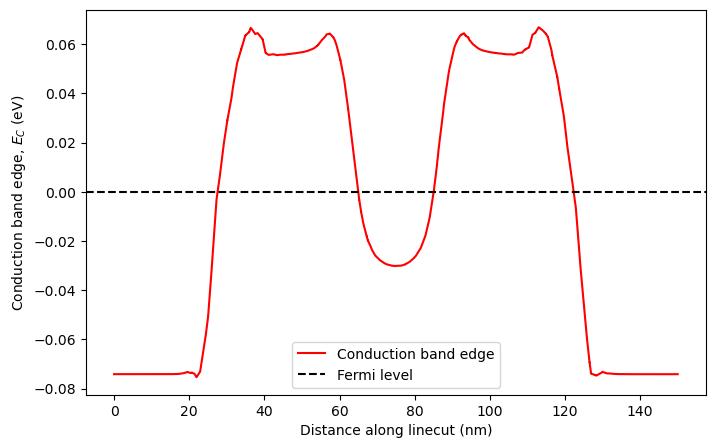

In [18]:
# Produce a linecut of the conduction band edge along the channel.
x, y, z = dvc.mesh.glob_nodes.T
ymin = np.min(y)
ymax = np.max(y)
distance, linecut_high_bias = an.linecut(
    dvc.mesh, dvc.cond_band_edge(), (0, ymin, 19e-9), (0, ymax, 19e-9)
)

# Plot the linecuts.
fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(1, 1, 1)
ax.set_xlabel("Distance along linecut (nm)")
ax.set_ylabel("Conduction band edge, $E_C$ (eV)")
ax.plot(distance / 1e-9, linecut_high_bias / ct.e, "-r", label="Conduction band edge")
ax.axhline(0, color="k", ls="--", label="Fermi level")
ax.legend()
plt.show()

As observed in the conduction band edge, there is a dip where the conduction band edge falls below the Fermi level.

This indicates that the states belw the fermi levels are occupied by the electrons.

Lastly, we can also save the results in the `.vtu` format.  

<div class="alert alert-block alert-info" style="background: #F4F4F4">

The `.vtu` (VTK Unstructured Grid) format is widely used for scientific visualization of finite-element data. It stores the mesh together with scalar and vector fields (such as electrostatic potential, charge density, etc.), making it well suited for post-processing.

These files can be directly opened in ParaView, where you can visualize the solution, create slices, inspect cross-sections, and generate high-quality plots of the simulation results.

For guidance on visualizing `.vtu` files in ParaView, please refer to [this tutorial](https://docs.nanoacademic.com/qtcad/tutorials/device/visualization_paraview/), which explains how to load the data, inspect the mesh, and explore the simulation results interactively.

</div>

In [19]:
# Save electrostatic properties in .vtu format.
out_dict = {
    "EC (eV)": dvc.cond_band_edge() / ct.e,
    "n (cm^-3)": dvc.n / 1e6,
}
io.save(path_out / "electrostatics.vtu", out_dict, mesh=dvc.mesh)

Saved data in C:\Proyecto_QTCAD\output\electrostatics.vtu
Estimated file size: 73.469 MB


c:\Users\aefra\anaconda3\envs\qtcad\Lib\site-packages\poissonfem\io.py:179: UserWarning: A large file (>10MB) was produced. Please make sure this is compatible with your memory capabilites.
  warn(i_590893280937259)


### 6. Single-particle electronic structure

Once the electrostatics of the device are solved, we can compute the single-particle electronic structure by solving the Schrödinger equation. The workflow is as follows:

1. Extract the **confinement potential** from the electrostatic potential obtained in the Poisson step.  
2. Define the **submesh** and the **subdevice** for the region of interest (dot region).  
3. Instantiate the **Schrödinger solver parameters**.  
4. Solve the **time-independent Schrödinger equation** to obtain the single-particle energy levels and wavefunctions.

#### Confinement potential

Next, we define the confinement potential $V$. Since the charge carriers are electrons, the confinement potential is simply:

$$
V =E_c
$$

where $\varphi$ is the electrostatic potential obtained from the Poisson solver.  

The `Device` class provides the [method `set_V_from_phi` 🔗](https://docs.nanoacademic.com/qtcad/API_reference/qtcad.device.device/#qtcad.device.device.Device.set_V_from_phi) to automatically set $V$ from $\varphi$.

In [20]:
# Get the confinement potential energy from the electric potential for usage in the Schrödinger solver.
dvc.set_V_from_phi()

#### `Submesh` and `SubDevice`

We use the same bounds defined for the dot region to create the **submesh** and the **subdevice**. The **corner method** introduced in Section 4 is applied here as well, specifying the two opposite corners of the region to define the 3D box for the subdevice.

In [21]:
# Create a submesh including only the dot region.
submesh = SubMesh(dvc.mesh, dvc.mesh.nodes_in_box(dot_region_box[0], dot_region_box[1]))
# Create a subdevice for the dot region.
subdvc = SubDevice(dvc, submesh)

3D SUBMESH STATISTICS
--------------------------------------------------------------------------------
Total number of elements      369951              
Triangular elements           35949               
Tetrahedral elements          334002              
Total number of nodes         58814               
Boundary physical names       spacer_1_bottom, spacer_2_bottom, channel_bottom, channel_side, gate_oxide_bottom, gate_oxide_top, barrier_gate_2, plunger_gate, barrier_gate_1, back_gate, 
Region physical names         box, spacer_1, spacer_2, channel, gate_oxide, 


#### Schrödinger solver parameters

We first create the Schrödinger solver parameters and set the convergence tolerance (`tol`). This ensures that the energy levels converge to the desired accuracy.


In [22]:
# Instantiate Schrodinger solver parameters.
params_schrod = SchrodingerSolverParams()
# · Tolerance on energies in eV.
params_schrod.tol = 1e-6

#### Schrödinger solver

Next, we instantiate the Schrödinger solver using the previously created **subdevice** (`subdvc`) and the defined solver parameters. We then solve the time-independent Schrödinger equation to obtain the single-particle energy levels and wavefunctions.

In [23]:
# Instantiate and run a Schrödinger solver.
schrodinger_slv = SchrodingerSolver(subdvc, solver_params=params_schrod)
schrodinger_slv.solve()

--------------------------------------------------------------------------------
Solving Schrödinger's equation for electrons.
--------------------------------------------------------------------------------
Schrodinger's equation solved in 11.36375720007345 s.


After solving the Schrödinger equation, we can print the energy levels in eV.  

In [24]:
# Print energy levels.
subdvc.print_energies()

Energy levels (eV)
[0.03183603 0.03534066 0.03977874 0.04483263 0.04725498 0.05049569 0.05111690 0.05505448 0.05826096 0.06012033]


Additionally, we can analyze statistical properties of the quantum dot, such as the average position of the confined electron, the standard deviation of the wavefunction, and other related quantities. These statistics can provide insights into the effective size and shape of the quantum dot, including estimates of the dot radius.

In [25]:
# Print the dot statistics
an.analyze_dot(subdvc, verbose=True);

--------------------------------------------------------------------------------
Geometric properties of the quantum dot:
--------------------------------------------------------------------------------
position        :  [-4.55653192e-10 -6.55246660e-11  1.80915264e-08]
std             :  [8.04372521e-09 3.84084591e-09 8.23268268e-10]
size            :  [3.21749008e-08 1.53633837e-08 3.29307307e-09]
--------------------------------------------------------------------------------


#### Post-processing

Finally, we save the Schrödinger solver results in `.vtu` format. This allows us to visualize the data in ParaView, just like with the Poisson results.  

We can also plot slices of the quantum dot’s ground and excited states to inspect the first few stationary wavefunctions and their spatial distribution within the dot.

In [26]:
# Save the wavefunctions in .vtu format.
ground = subdvc.eigenfunctions[:, 0]
out_dict = {
    "Ground state": subdvc.eigenfunctions[:, 0],
    "First excited state": subdvc.eigenfunctions[:, 1],
    "Second excited state": subdvc.eigenfunctions[:, 2],
}
io.save(path_out / "schrodinger.vtu", out_dict, mesh=subdvc.mesh)

Saved data in C:\Proyecto_QTCAD\output\schrodinger.vtu
Estimated file size: 72.463 MB


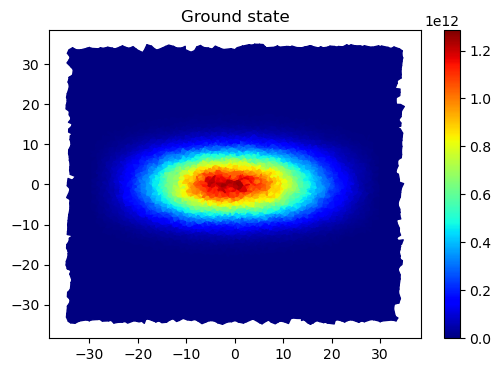

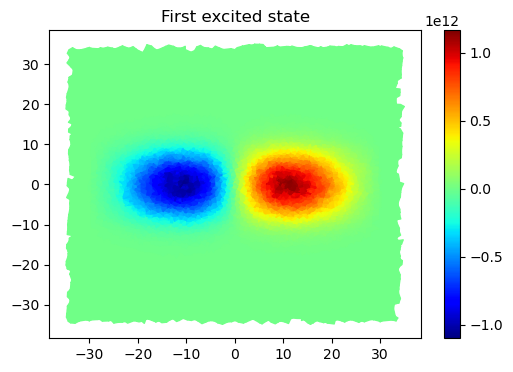

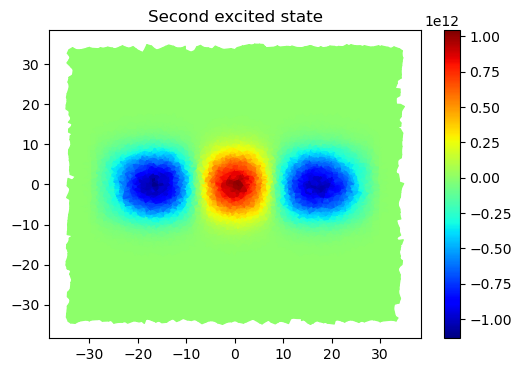

In [27]:
an.plot_slice(
    subdvc.mesh,
    subdvc.eigenfunctions[:, 0],
    (0, 0, 1),
    (0, 0, 19e-9),
    title="Ground state",
)
an.plot_slice(
    subdvc.mesh,
    subdvc.eigenfunctions[:, 1],
    (0, 0, 1),
    (0, 0, 19e-9),
    title="First excited state",
)
an.plot_slice(
    subdvc.mesh,
    subdvc.eigenfunctions[:, 2],
    (0, 0, 1),
    (0, 0, 19e-9),
    title="Second excited state",
)

From the cross-sections of the wavefunctions, we can observe the ground state and the first two excited states of the confined quantum dot. Physically, what can be measured or visualized is the **probability density**, given by the absolute square of the wavefunction, $|\psi|^2$. This represents the probability of finding an electron in a given region of space.

#### Optional Exercise

We encourage you to plot the probability densities $|\psi|^2$ for the ground state and the excited states to visualize how the electron is confined within the quantum dot.


## Final considerations

In this notebook, we covered the basic electrostatic and Schrödinger simulation of a single quantum dot in an FD-SOI structure. Specifically, we demonstrated:

- Non-linear Poisson simulation with gate boundary conditions.  
- Adaptive meshing and its relevant solver parameters to refine the mesh where needed.  
- Solving the single-particle states using the Schrödinger equation and analyzing the resulting energy levels and wavefunctions.

In the next session, we will introduce lever-arm theory and its corresponding solver in QTCAD® and discuss its applications and benefits for quantum dot devices.